In [45]:
%load_ext autoreload
%autoreload 2
import os
import glob
import numpy as np
import h5py
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Dataset
import sys
sys.path.append('../../src/benchmark/')
sys.path.append('../../src/utils/')
from build_model import resnet50_, densenet161_, fpn_resnet50_classification, xcit_small
from utils import hdf5_dataset, list_to_dict, viz_dataloader
from prediction_analysis import confusion_matrix, plot_cm, prediction_vs_actual, most_confused, show_cm
from viz import show_images

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [55]:
import numpy as np

def change_color_palette_np(image, green_range, target_color):
    """
    Changes the green color in the image to the target color based on the specified green range.

    Args:
        image (numpy.ndarray): Input image.
        green_range (tuple): A tuple specifying the range of the green channel (min, max).
        target_color (tuple): The target color to replace the green color with.

    Returns:
        numpy.ndarray: Image with changed color.
    """
    # Create a copy of the image to modify
    new_image = image.copy()

    # Extract the green channel
    green_channel = image[:, :, 1]

    # Create a mask for pixels within the specified green range
    mask = (green_channel >= green_range[0]) & (green_channel <= green_range[1])

    # Apply the mask to change the color of the pixels within the range
    new_image[mask] = target_color

    return new_image


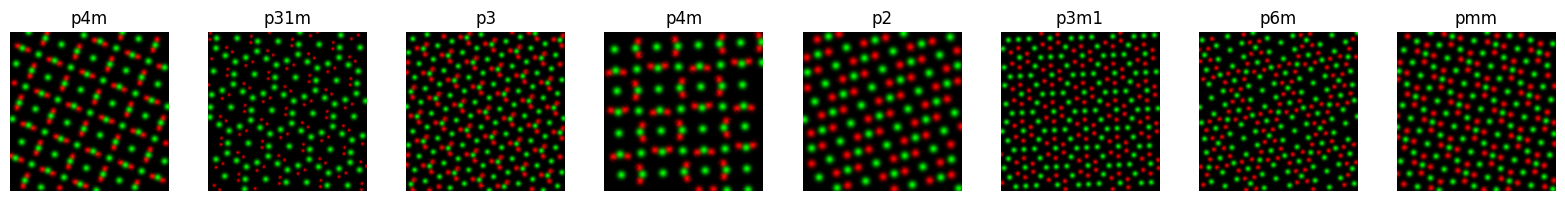

In [57]:
from torchvision import transforms
from torch.utils.data import DataLoader

# Define the range for the green channel and the target color
green_range = (1e-3, 1)  # Adjust this range based on your specific needs
target_color = (0, 0, 1)  # Example: change green to blue

# Define the transformation pipeline
transform = transforms.Compose([
    transforms.Lambda(lambda img: change_color_palette_np(img, green_range, target_color)),
    transforms.ToTensor(),
])

symmetry_classes = ['p1', 'p2', 'pm', 'pg', 'cm', 'pmm', 'pmg', 'pgg', 'cmm', 'p4', 'p4m', 'p4g', 'p3', 'p3m1', 'p31m', 'p6', 'p6m']
label_converter = list_to_dict(symmetry_classes)

# Load your dataset with the custom transformation
train_ds = hdf5_dataset('../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset.h5', folder='atom', transform=transform)
train_dl = DataLoader(train_ds, batch_size=1028, shuffle=False, num_workers=2)

# Visualize the data loader (assuming viz_dataloader is a function you have defined)
viz_dataloader(train_dl, label_converter=label_converter)

(array([1.49173527e+08, 6.00357700e+06, 5.11504400e+06, 2.36760400e+06,
        2.29078500e+06, 2.57766900e+06, 1.55641300e+06, 1.61896400e+06,
        1.00391500e+06, 1.50992700e+06, 1.34078300e+06, 9.60683000e+05,
        3.92926000e+05, 1.84759100e+06, 5.42289000e+05, 1.24937300e+06,
        1.39271000e+05, 5.01226000e+05, 5.32008000e+05, 1.16250700e+06,
        2.72605000e+05, 1.13549500e+06, 1.70463000e+05, 5.54921000e+05,
        3.94607000e+05, 5.46154000e+05, 5.47039000e+05, 2.68000000e+02,
        8.80618000e+05, 5.13010000e+05, 7.25920000e+04, 5.46465000e+05,
        5.45511000e+05, 3.43612000e+05, 2.98600000e+05, 6.97270000e+04,
        7.75423000e+05, 2.99674000e+05, 2.40950000e+05, 2.68179000e+05,
        0.00000000e+00, 6.41009000e+05, 2.58195000e+05, 4.85034000e+05,
        1.12000000e+02, 1.40733000e+05, 2.59083000e+05, 6.49569000e+05,
        3.49860000e+04, 4.63772000e+05, 5.12954000e+05, 5.60000000e+01,
        2.06682000e+05, 7.01210000e+04, 5.60000000e+01, 4.510430

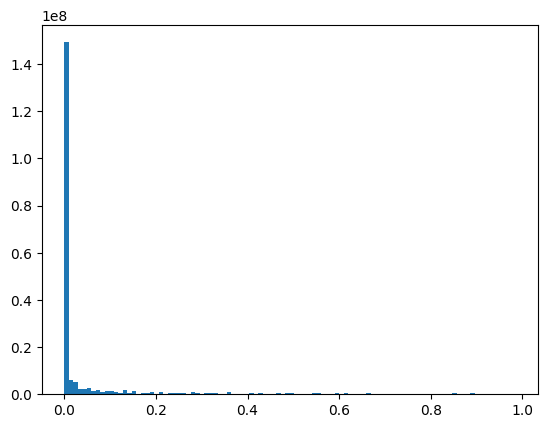

In [53]:
batch = next(iter(train_dl))
images, labels = batch
plt.hist(images.numpy().flatten(), bins=100)

In [ ]:
from torchvision import transforms
from torch.utils.data import DataLoader

# Define your color mapping
color_mapping = {
    (0, 255, 0): (0, 0, 255),  # Example: change pure green to pure blue
}

# Define the transformation pipeline
transform = transforms.Compose([
    transforms.Lambda(lambda img: change_color_palette(img, color_mapping)),
    transforms.ToTensor(),
])

# Load your dataset with the custom transformation
train_ds = hdf5_dataset('../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset.h5', folder='atom', transform=transform)
train_dl = DataLoader(train_ds, batch_size=1028, shuffle=False, num_workers=2)

In [49]:
batch = next(iter(train_dl))

AttributeError: Caught AttributeError in DataLoader worker process 0.
Original Traceback (most recent call last):
  File "/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torch/utils/data/_utils/worker.py", line 308, in _worker_loop
    data = fetcher.fetch(index)
  File "/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torch/utils/data/_utils/fetch.py", line 51, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torch/utils/data/_utils/fetch.py", line 51, in <listcomp>
    data = [self.dataset[idx] for idx in possibly_batched_index]
  File "/home/yichen/Understanding-Experimental-Images-by-Identifying-Symmetries-with-Deep-Learning/notebooks/Benchmark/../../src/utils/utils.py", line 139, in __getitem__
    image = self.transform(image)
  File "/home/yichen/anaconda3/envs/symmetry/lib/python3.10/site-packages/torchvision/transforms/transforms.py", line 95, i

In [ ]:

# Visualize the data loader (assuming viz_dataloader is a function you have defined)
viz_dataloader(train_dl, label_converter=label_converter)


In [8]:
with h5py.File('../../datasets/imagenet_atom_noise_v4_rot_10m_100k_subset.h5', 'r') as h5:
    imgs = np.array(h5['atom']['data'][:16])

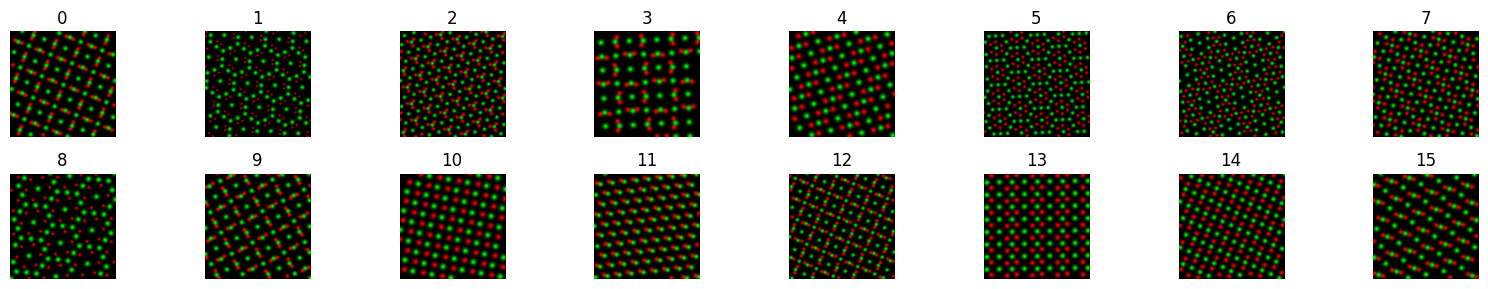

In [9]:
show_images(imgs)

In [17]:
img = imgs[0]
print(np.sum(img[:,:,0]), np.sum(img[:,:,1]), np.sum(img[:,:,2]))
print(img.shape)

1329800 1655296 0
(256, 256, 3)


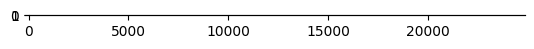

In [16]:
mask = np.nonzero(img[:,:,0])
plt.imshow(mask)

In [39]:
import numpy as np
import cv2

def draw_atom(image, coordinate, r, color='white', noise=False):
    '''
    f(x) = a*(exp(-(x-mu)^2)/2*sigma^2), 
    a is the height of curve's peak, 
    mu is the position of the center of the peak,
    and sigma controls the width of the 'bell'.
    '''
    image_d = np.copy(image)
    
    h, w = image_d.shape[:2]
    x, y = round(coordinate[0]), round(coordinate[1])
    i, j = np.meshgrid(np.linspace(-1, 1, 2 * r), np.linspace(-1, 1, 2 * r))
    d = np.sqrt(i * i + j * j)
    sigma, mu = 0.38, 0.0
    g = np.exp(-( (d - mu) ** 2 / (2.0 * sigma ** 2)))
    g_rgb = np.dstack([g, g, g])
    g_rgb[g_rgb < 5e-2] = 0  # clean up the edges so overlapping of two atoms are not too obvious

    color_dict = {'red': [1, 0, 0], 'green': [0, 1, 0], 'blue': [0, 0, 1], 'white': [1, 1, 1]}

    if noise:
        noise_matrix = np.random.random((2 * r, 2 * r, 3))
        g_rgb = g_rgb * noise_matrix
        if color in color_dict:
            g_rgb *= color_dict[color]
    else:
        if color in color_dict:
            g_rgb *= color_dict[color]

    if x + r > w or x - r < 0 or y + r > h or y - r < 0:
        atom_padded = np.zeros((np.max((y + r, h)) - np.min((y - r, 0)), np.max((x + r, w)) - np.min((x - r, 0)), 3))
        x_ = x - np.min((0, x - r))
        y_ = y - np.min((0, y - r))

        atom_padded[int(y_ - r): int(y_ + r), x_ - r:x_ + r, :] += g_rgb
            
        atom = np.copy(atom_padded[0 - np.min((0, y - r)):h - np.min((0, y - r)), 0 - np.min((0, x - r)):w - np.min((0, x - r)), :])

    else:
        atom = np.zeros((h, w, 3))
        atom[int(y - r): int(y + r), x - r:x + r, :] += g_rgb

    image_d += atom
    return image_d


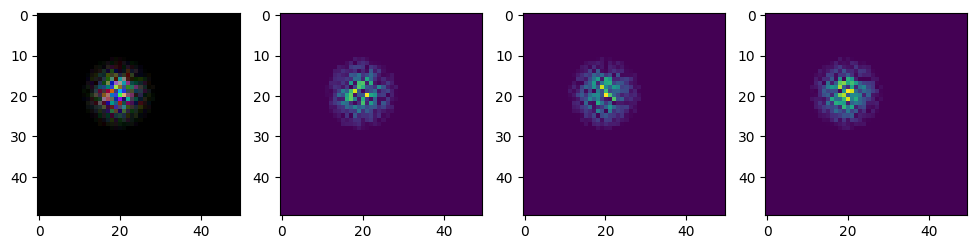

In [43]:
img = np.zeros((50,50,3))
out = draw_atom(img, (20,20), r=10, color='white', noise=True)
fig, axes = plt.subplots(1,4, figsize=(12,3))
axes[0].imshow(out)
axes[1].imshow(out[:,:,0])
axes[2].imshow(out[:,:,1])
axes[3].imshow(out[:,:,2])
plt.show()

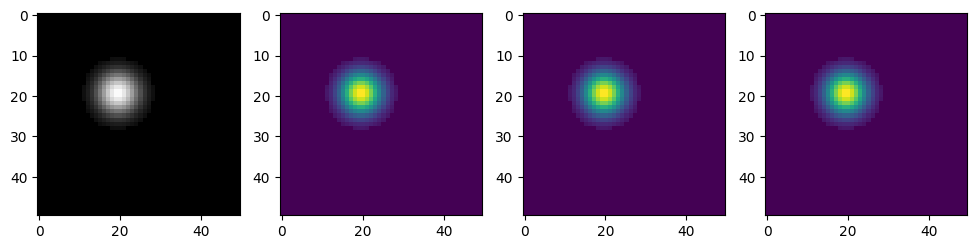

In [42]:
img = np.zeros((50,50,3))
out = draw_atom(img, (20,20), r=10, color='white', noise=False)
fig, axes = plt.subplots(1,4, figsize=(12,3))
axes[0].imshow(out)
axes[1].imshow(out[:,:,0])
axes[2].imshow(out[:,:,1])
axes[3].imshow(out[:,:,2])
plt.show()

In [18]:

# basic functions:
def draw_atom(image, coordinate, r, color='white'): # making white dot, assuming black image background
    '''
    f(x) = a*(exp(-(x-mu)^2)/2*sigma^2), 
    a is the height of curve's peak, 
    mu is the position of the center of the peak,
    and sigma controls the width of the 'bell'.
    '''
    image_d = np.copy(image)
    
    h,w = image_d.shape[:2]
    x, y = round(coordinate[0]), round(coordinate[1])
    i, j = np.meshgrid(np.linspace(-1,1,2*r), np.linspace(-1,1,2*r))
    d = np.sqrt(i*i+j*j)
    sigma, mu = 0.38, 0.0
    g = np.exp(-( (d-mu)**2 / ( 2.0 * sigma**2 ) ) )
    g_rgb = np.dstack([g,g,g])
    g_rgb[g_rgb<5e-2]=0 #clean up the edges so overlapping of two atoms are not too obvious

    color_dict = {'red':0, 'green':1, 'blue':2}

    if x+r>w or x-r<0 or y+r>h or y-r<0:
        atom_padded = np.zeros((np.max((y+r,h))-np.min((y-r,0)), np.max((x+r,w))-np.min((x-r,0)), 3))
        x_ = x - np.min((0,x-r))
        y_ = y - np.min((0,y-r))

        if color == 'white':
            atom_padded[int(y_-r): int(y_+r), x_-r:x_+r, :] += g_rgb
            
        elif color == 'c1':
            atom_padded[int(y_-r): int(y_+r), x_-r:x_+r, 0] += g
            atom_padded[int(y_-r): int(y_+r), x_-r:x_+r, 1] += g*0.8
            atom_padded[int(y_-r): int(y_+r), x_-r:x_+r, 2] += g*0.4
            
        elif color == 'c2':
            atom_padded[int(y_-r): int(y_+r), x_-r:x_+r, 0] += g
            atom_padded[int(y_-r): int(y_+r), x_-r:x_+r, 1] += g*0.8
            atom_padded[int(y_-r): int(y_+r), x_-r:x_+r, 2] += g*0.4
            
        else:
            atom_padded[int(y_-r): int(y_+r), x_-r:x_+r, color_dict[color]] += g
            
        atom = np.copy(atom_padded[0-np.min((0,y-r)):h-np.min((0,y-r)), 0-np.min((0,x-r)):w-np.min((0,x-r)), :])

    else:
        atom = np.zeros((h,w,3))

        if color == 'white':
            atom[int(y-r): int(y+r), x-r:x+r, :] += g_rgb
            
        elif color == 'c1':
            atom[int(y-r): int(y+r), x-r:x+r, 0] += g
            atom[int(y-r): int(y+r), x-r:x+r, 1] += g*0.8
            atom[int(y-r): int(y+r), x-r:x+r, 2] += g*0.3
            
        elif color == 'c2':
            atom[int(y-r): int(y+r), x-r:x+r, 0] += g*0.5
            atom[int(y-r): int(y+r), x-r:x+r, 1] += g*0.3
            atom[int(y-r): int(y+r), x-r:x+r, 2] += g*0.8
            
        else:
            atom[int(y-r): int(y+r), x-r:x+r, color_dict[color]] += g
    image_d += atom
    return image_d

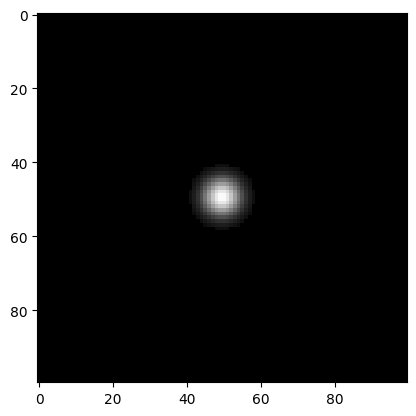

In [20]:
img = np.zeros((100,100,3))
out = draw_atom(img, (50,50), r=10, color='noise')
plt.imshow(out)